In [31]:
from pathlib import Path
import torch
import random
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent



In [32]:
from torch.utils.data import Dataset
from PIL import Image
import os

class PlasticBinaryDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = [
            f for f in os.listdir(root_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if "bad" in img_name.lower():
            label = 1
        else:
            label = 0

        if self.transform:
            image = self.transform(image)

        return image, label

In [33]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [34]:
PLASTIC_DIR = PROJECT_ROOT / "TP26_plastic_v1"

plastic_train_ds = PlasticBinaryDataset(
    PLASTIC_DIR / "train",
    transform=train_tf
)

plastic_val_ds = PlasticBinaryDataset(
    PLASTIC_DIR / "valid",
    transform=eval_tf
)

plastic_test_ds = PlasticBinaryDataset(
    PLASTIC_DIR / "test",
    transform=eval_tf
)
plastic_train_loader = DataLoader(
    plastic_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True
)

plastic_val_loader = DataLoader(
    plastic_val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

plastic_test_loader = DataLoader(
    plastic_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Počet plastových test obrázkov:", len(plastic_test_ds))

Počet plastových test obrázkov: 122


In [35]:
import torchvision.models as models
from torch import nn

binary_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

binary_model.fc = nn.Linear(binary_model.fc.in_features, 2)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(binary_model.parameters(), lr=1e-4)

In [ ]:
EPOCHS = 5

for epoch in range(EPOCHS):
    binary_model.train()
    train_loss, train_correct = 0, 0

    for images, labels in plastic_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = binary_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    train_acc = train_correct / len(plastic_train_ds)

    binary_model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in plastic_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = binary_model(images)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    val_acc = val_correct / len(plastic_val_ds)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}"
    )

Epoch 1/10 | Train Acc: 0.913 | Val Acc: 0.992
Epoch 2/10 | Train Acc: 0.983 | Val Acc: 0.984
Epoch 3/10 | Train Acc: 0.984 | Val Acc: 0.984
Epoch 4/10 | Train Acc: 0.994 | Val Acc: 0.959
Epoch 5/10 | Train Acc: 0.992 | Val Acc: 0.992
Epoch 6/10 | Train Acc: 0.990 | Val Acc: 0.992
Epoch 7/10 | Train Acc: 0.997 | Val Acc: 0.992
Epoch 8/10 | Train Acc: 0.997 | Val Acc: 0.984
Epoch 9/10 | Train Acc: 0.995 | Val Acc: 0.992
Epoch 10/10 | Train Acc: 0.996 | Val Acc: 0.992


              precision    recall  f1-score   support

        GOOD       1.00      1.00      1.00        52
      DEFECT       1.00      1.00      1.00        70

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



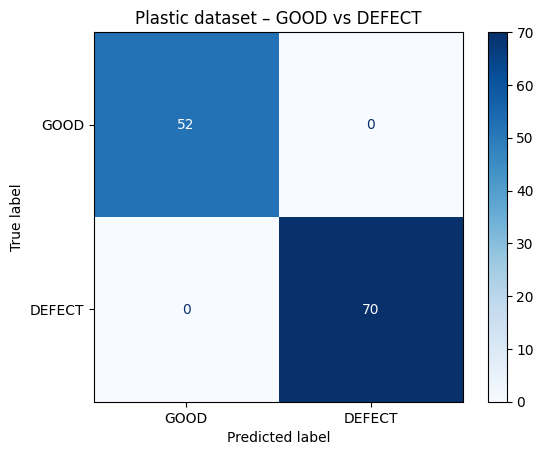

In [37]:
binary_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in plastic_test_loader:
        images = images.to(device)
        outputs = binary_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(
    all_labels, all_preds,
    target_names=["GOOD", "DEFECT"]
))

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["GOOD", "DEFECT"]).plot(
    cmap="Blues"
)
plt.title("Plastic dataset – GOOD vs DEFECT")
plt.show()


In [38]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self._forward_hook)
        self.target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, class_idx=None):
        self.model.eval()

        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[:, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)
        cam = torch.relu(cam)
        cam = cam.squeeze().detach().cpu().numpy()
        cam = cam / cam.max()

        return cam

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_gradcam_n_per_class(
    model,
    grad_cam,
    loader,
    class_names,
    n_per_class=5
):
    model.eval()

    class_counter = {cls: 0 for cls in class_names}

    n_classes = len(class_names)
    total_plots = n_classes * n_per_class

    plt.figure(figsize=(4 * n_per_class, 4 * n_classes))
    plot_idx = 1

    for images, labels in loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(images.size(0)):
            pred_idx = preds[i].item()
            class_name = class_names[pred_idx]

            if class_counter[class_name] >= n_per_class:
                continue

            cam = grad_cam(images[i:i+1])
            img = images[i].cpu()

            img_np = img.permute(1, 2, 0).numpy()
            H, W, _ = img_np.shape
            cam_resized = cv2.resize(cam, (W, H))

            heatmap = cv2.applyColorMap(
                np.uint8(255 * cam_resized),
                cv2.COLORMAP_JET
            )
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = 0.6 * img_np + 0.4 * (heatmap / 255)

            plt.subplot(n_classes, n_per_class, plot_idx)
            plt.imshow(overlay)
            plt.title(class_name, fontsize=9)
            plt.axis("off")

            plot_idx += 1
            class_counter[class_name] += 1

            if all(class_counter[c] >= n_per_class for c in class_names):
                plt.tight_layout()
                plt.show()
                return

    plt.tight_layout()
    plt.show()

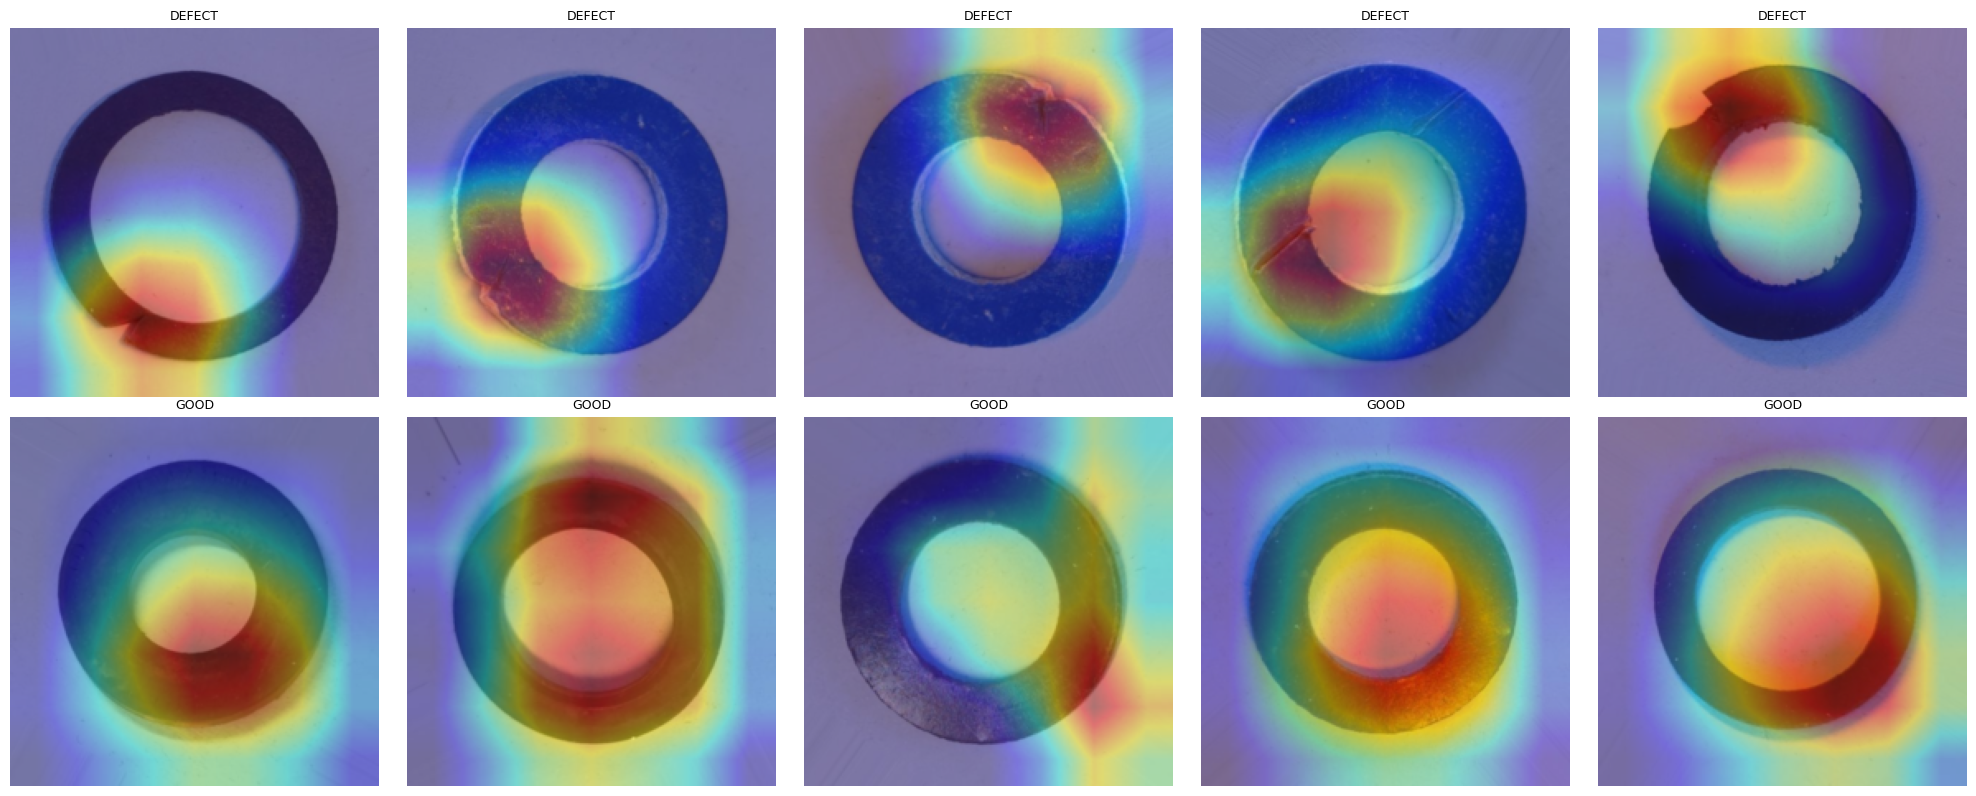

In [40]:

show_gradcam_n_per_class(
    model=binary_model,
    grad_cam=GradCAM(binary_model, binary_model.layer4[-1].conv2),
    loader=plastic_test_loader,
    class_names=["GOOD", "DEFECT"],
    n_per_class=5
)
